In [1]:
from matplotlib.backends.backend_pdf import PdfPages

#Basic Setup
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math
#open root file


#df = uproot.open(
 #   "/volatile/clas12/cooperb/SULI/pid_training_test.root:PhysicsEvents"
#).arrays(library="pd")
cols = ["pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]

#cols = ["mc_matching_pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]

df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v2.root:PhysicsEvents").arrays(cols, library="pd")
real =uproot.open("/volatile/clas12/cooperb/SULI/data_pid_training_test.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)
#matched = df[df["mc_matching_pid"] != -9999].copy()
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(matched["mc_matching_pid"]==321)&passes_kplus_chi2pid_cut(matched["chi2pid"], matched["p"])]
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(abs(matched["chi2pid"])<1)]
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/subtract/group1/"  #path directory for saving pngs :)
#matched=baseline

#matched = matched[(matched["nphe_htcc"]!=-9999)&(matched["nphe_htcc"]!=0)]
#print("ftof_path_1A:  ", matched["nphe_htcc"].describe())
#print("\nQuick eyeball:")
#print(f"  ftof_time_1A range: [{matched['nphe_htcc'].min():.2f}, {matched['nphe_htcc'].max():.2f}]")

allPlots=[]

In [2]:
ranges=[
[-2212, 2212], #pid
[0.5, 5],    #p
[4, 44], #theta
[0, 1],  #beta  
[-10, 10], #chi2pid
[0,1], #rich_RQ
[-10,2], #Vz (Real data has hard cut a 0.6
[0, 6], #sector
[0,360]  #Phi  
]    

parts = [321, 211, 2212]
colors= ["Red", "Blue"]
labels=["Data", "Monte-Carlo"]

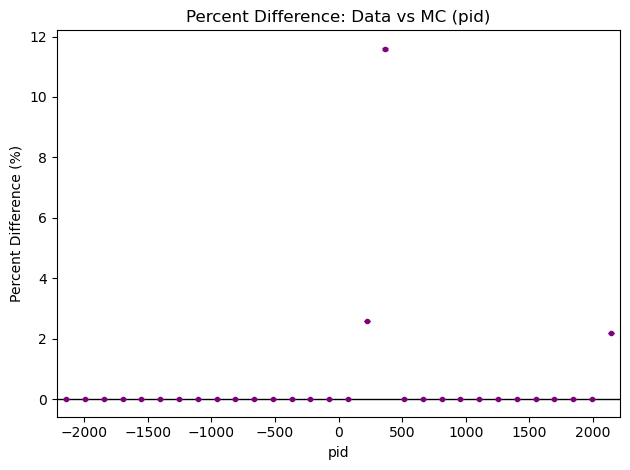

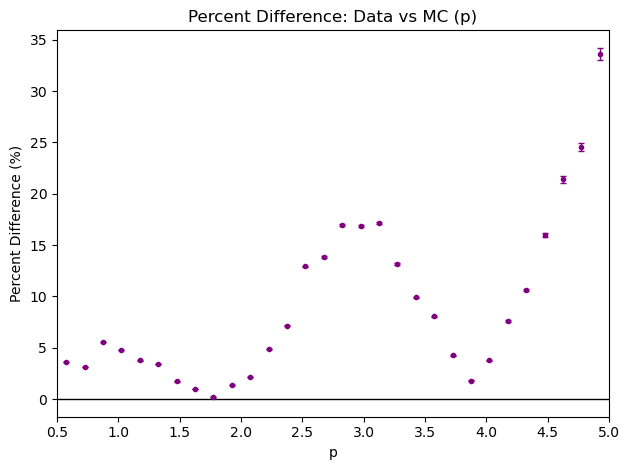

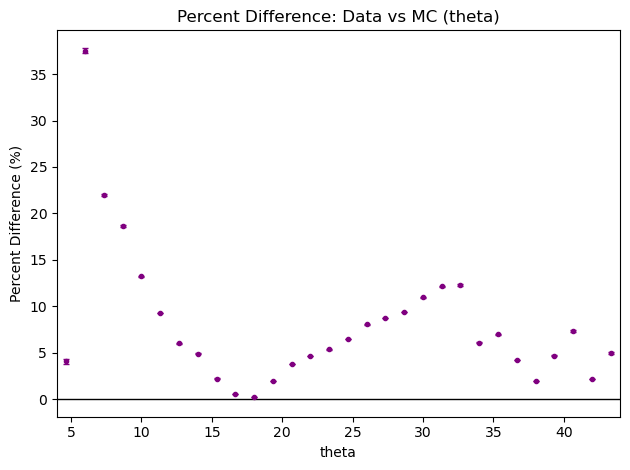

/scratch/slurm/5054438/.cache/tmp/ipykernel_2794473/881264317.py:48: RuntimeWarning: invalid value encountered in divide
  (mc_err[mask] / mc_norm[mask])**2


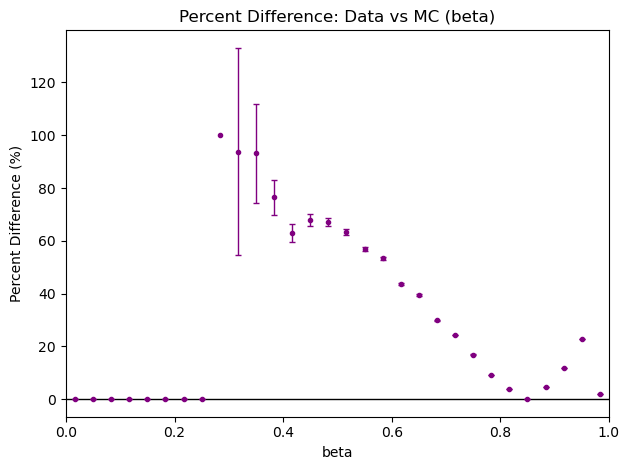

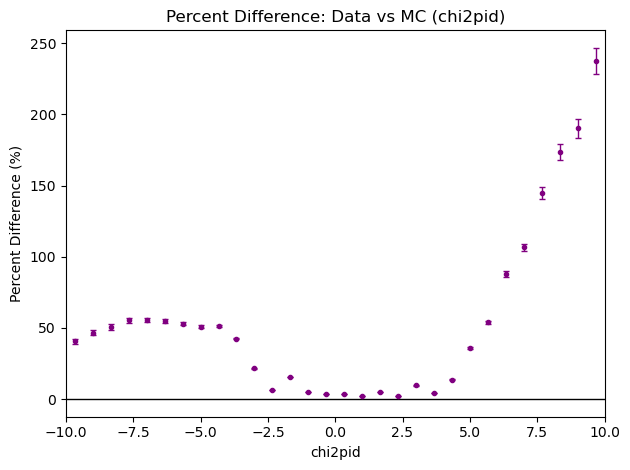

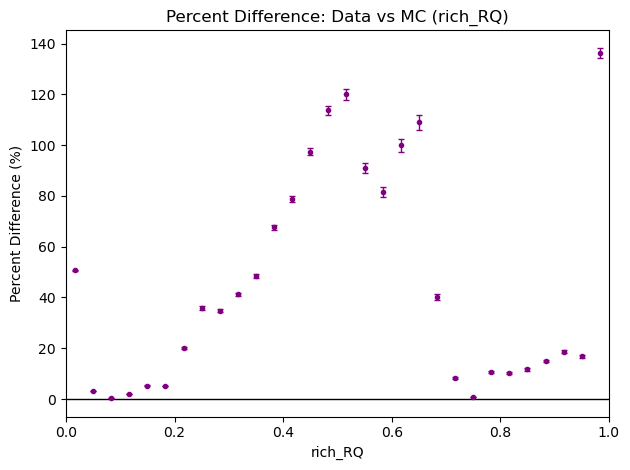

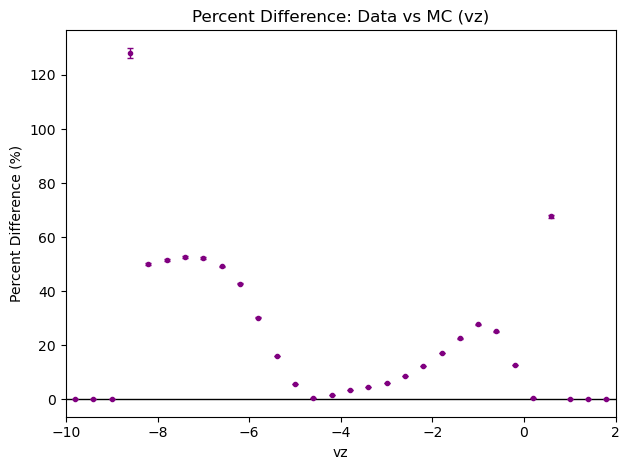

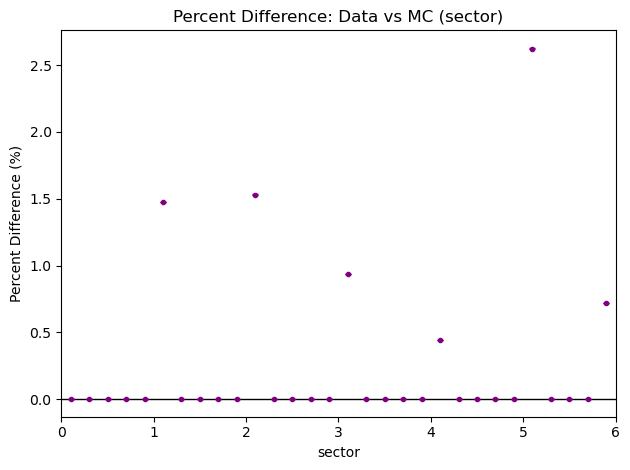

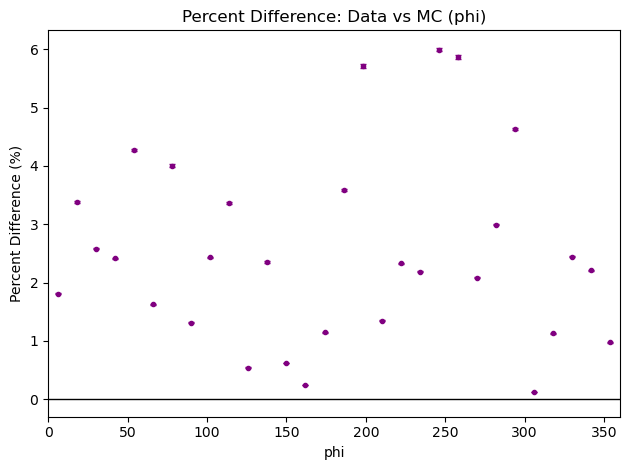

In [3]:
cnt = 0

for varbs in cols:

    real_data = real[real[varbs] != -9999]
    mc_data = df[df[varbs] != -9999]

    rng = (ranges[cnt][0], ranges[cnt][1])
    bins = 30

    # --- raw histograms ---
    real_counts, edges = np.histogram(
        real_data[varbs],
        bins=bins,
        range=rng
    )

    mc_counts, _ = np.histogram(
        mc_data[varbs],
        bins=bins,
        range=rng
    )

    real_tot = real_counts.sum()
    mc_tot = mc_counts.sum()

    # --- normalized histograms ---
    real_norm = real_counts / real_tot
    mc_norm = mc_counts / mc_tot

    # --- uncertainties AFTER normalization ---
    real_err = np.sqrt(real_counts) / real_tot
    mc_err = np.sqrt(mc_counts) / mc_tot

    # --- percent difference ---
    mask = real_norm != 0
    percent_diff = np.zeros_like(real_norm)

    percent_diff[mask] = (
        abs((real_norm[mask] - mc_norm[mask]) / real_norm[mask]
    ) * 100)

    # --- propagated uncertainty on percent diff ---
    percent_err = np.zeros_like(real_norm)

    percent_err[mask] = np.abs(percent_diff[mask]) * np.sqrt(
        (real_err[mask] / real_norm[mask])**2 +
        (mc_err[mask] / mc_norm[mask])**2
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    # --- plot ---
    fig, ax = plt.subplots()

    ax.axhline(0, color="black", linewidth=1)

    ax.errorbar(
        centers,
        percent_diff,
        yerr=percent_err,
        fmt='o',
        color='purple',
        markersize=3,
        elinewidth=1,
        capsize=2
    )

    ax.set_xlabel(varbs)
    ax.set_ylabel("Percent Difference (%)")
    ax.set_title(f"Percent Difference: Data vs MC ({varbs})")
    ax.set_xlim(rng)

    fig.tight_layout()
    fig.savefig(direct + varbs + "Difference.png", dpi=150)

    plt.show()
    allPlots.append(fig)
    plt.close(fig)

    cnt += 1

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math

#cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]
cols = ["pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]

df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v2.root:PhysicsEvents").arrays(cols, library="pd")
real =uproot.open("/volatile/clas12/cooperb/SULI/data_pid_training_test.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)

In [5]:
ranges=[
[-2212,2212], #pid
[0, 25],    #ftof_energy_1A
[0, 25], #ftof_energy_1B
[20, 50],  # ftof_time_1A
[20, 50], #ftof_time_1B
[600,800], #ftof_path_1A
[600,800], #ftof_path_1B
[0, 1], #ecin_energy
[0,1],  #ecout_energy
[20,50], #ecin_time 
[20,50], #ecout_time 
[733,800], #ecin_path
[733,800], #ecout_path
[1,16] #nphe_htcc    
]    
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/subtract/group2/"  #path directory for saving pngs :)

colors= ["Red", "Blue"]
labels=["Data", "Monte-Carlo"]

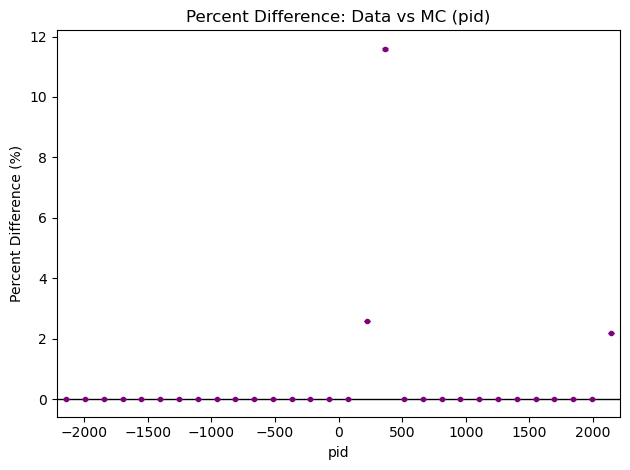

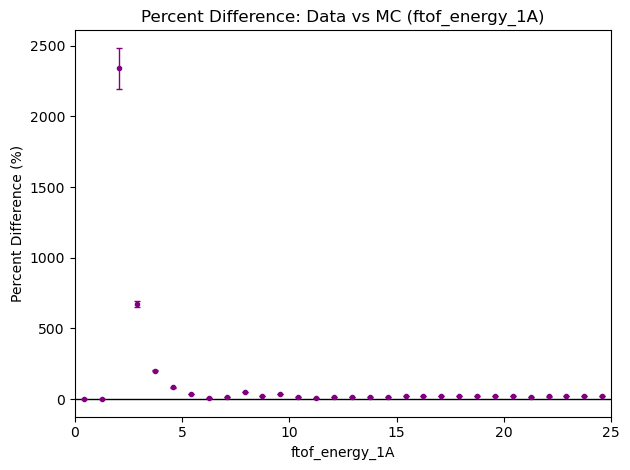

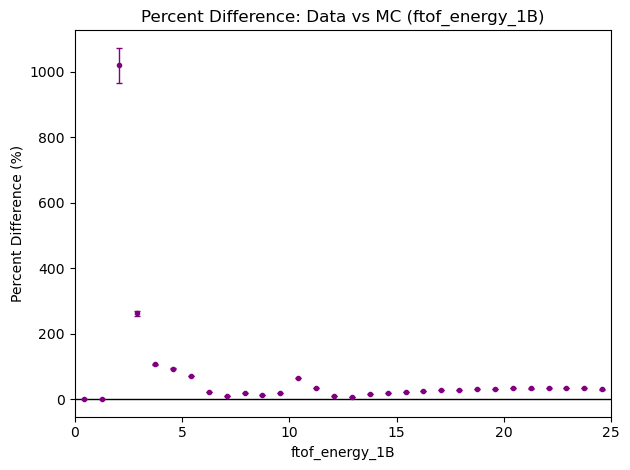

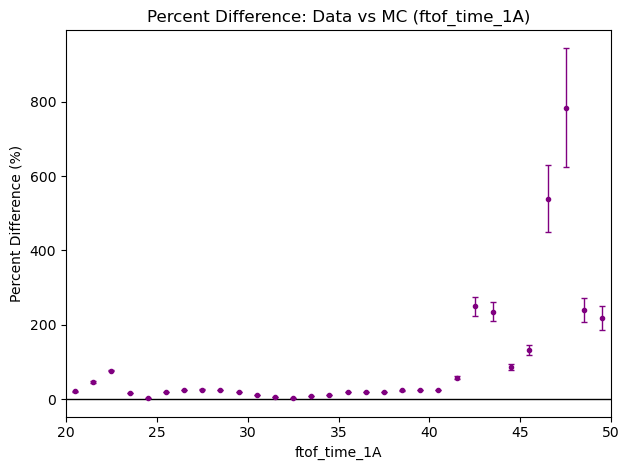

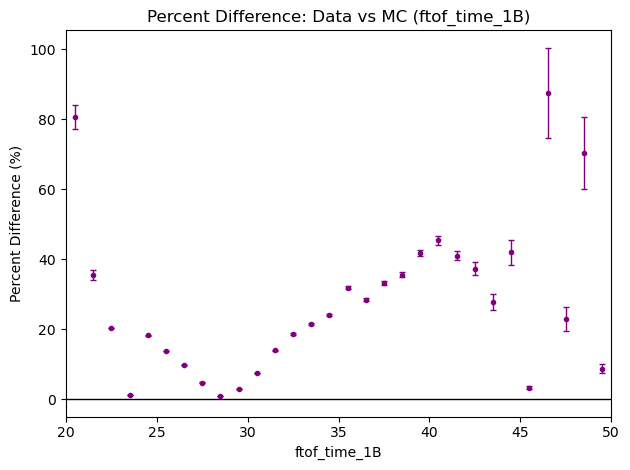

/scratch/slurm/5054438/.cache/tmp/ipykernel_2794473/881264317.py:48: RuntimeWarning: invalid value encountered in divide
  (mc_err[mask] / mc_norm[mask])**2


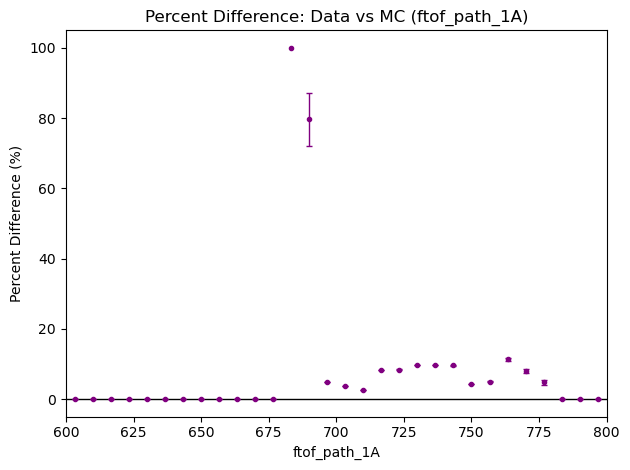

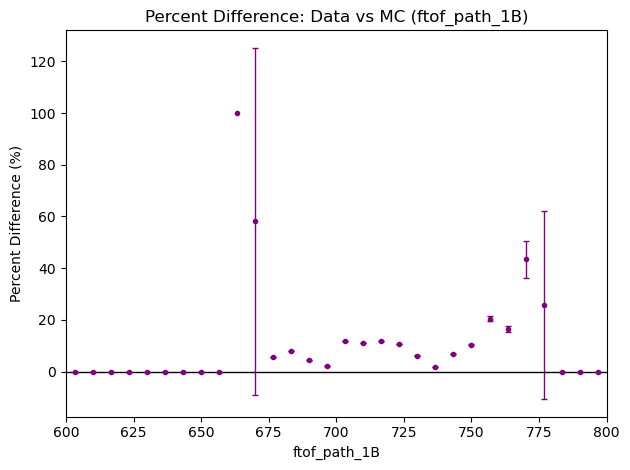

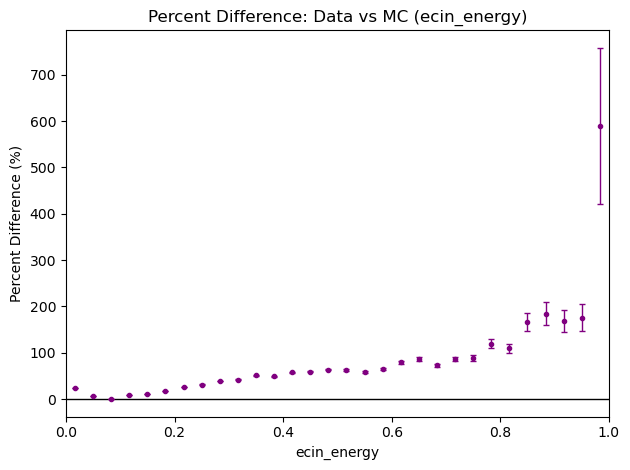

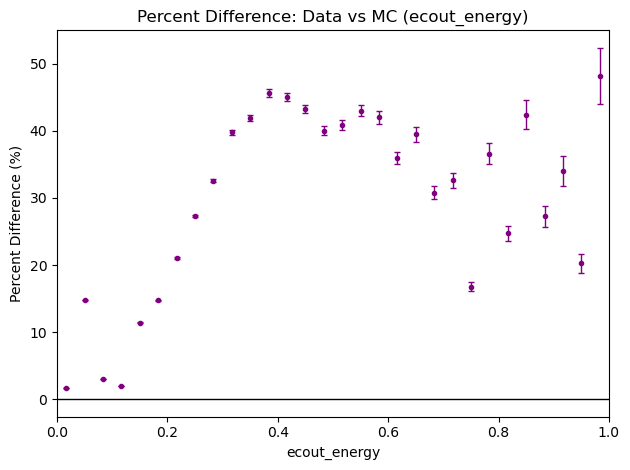

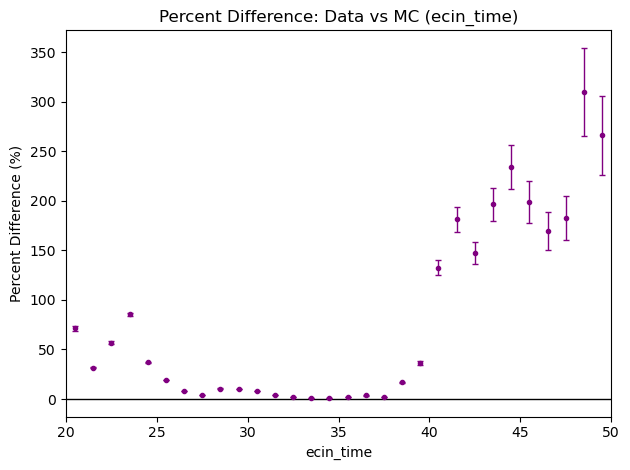

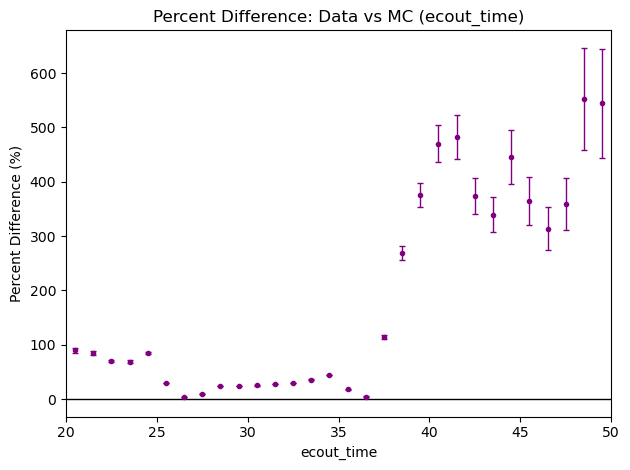

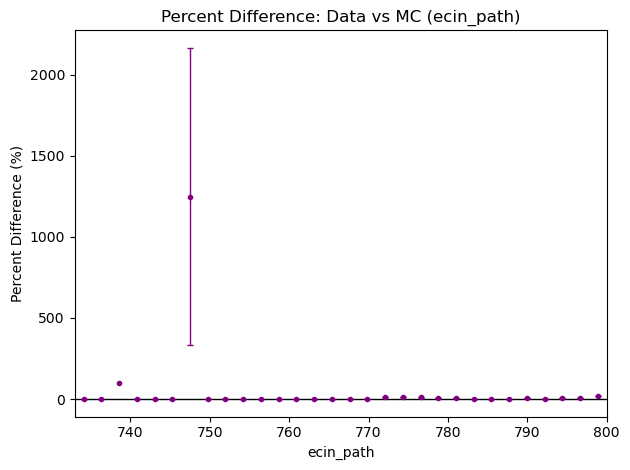

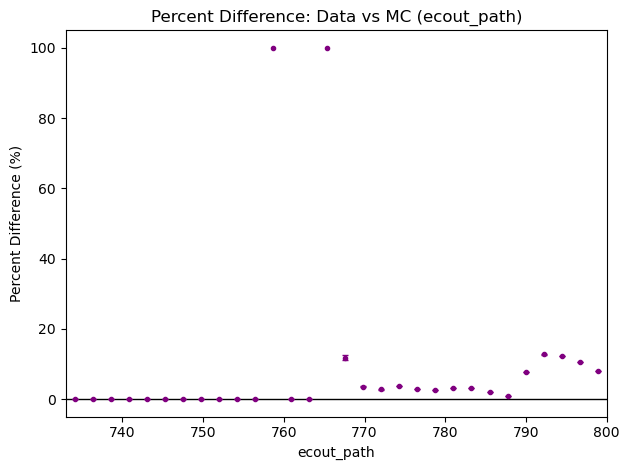

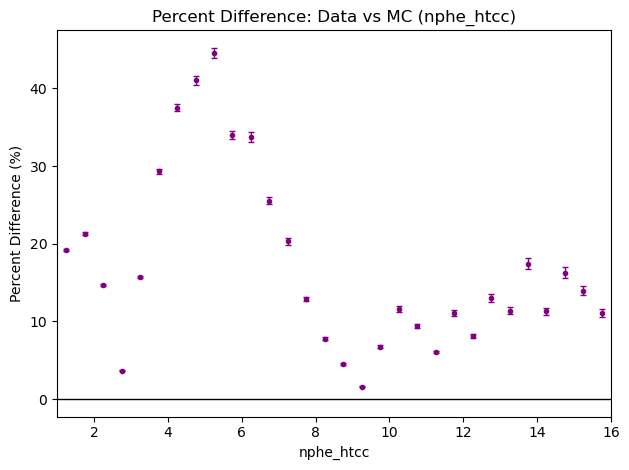

In [6]:
cnt = 0

for varbs in cols:

    real_data = real[real[varbs] != -9999]
    mc_data = df[df[varbs] != -9999]

    rng = (ranges[cnt][0], ranges[cnt][1])
    bins = 30

    # --- raw histograms ---
    real_counts, edges = np.histogram(
        real_data[varbs],
        bins=bins,
        range=rng
    )

    mc_counts, _ = np.histogram(
        mc_data[varbs],
        bins=bins,
        range=rng
    )

    real_tot = real_counts.sum()
    mc_tot = mc_counts.sum()

    # --- normalized histograms ---
    real_norm = real_counts / real_tot
    mc_norm = mc_counts / mc_tot

    # --- uncertainties AFTER normalization ---
    real_err = np.sqrt(real_counts) / real_tot
    mc_err = np.sqrt(mc_counts) / mc_tot

    # --- percent difference ---
    mask = real_norm != 0
    percent_diff = np.zeros_like(real_norm)

    percent_diff[mask] = (
        abs((real_norm[mask] - mc_norm[mask]) / real_norm[mask]
    ) * 100)

    # --- propagated uncertainty on percent diff ---
    percent_err = np.zeros_like(real_norm)

    percent_err[mask] = np.abs(percent_diff[mask]) * np.sqrt(
        (real_err[mask] / real_norm[mask])**2 +
        (mc_err[mask] / mc_norm[mask])**2
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    # --- plot ---
    fig, ax = plt.subplots()

    ax.axhline(0, color="black", linewidth=1)

    ax.errorbar(
        centers,
        percent_diff,
        yerr=percent_err,
        fmt='o',
        color='purple',
        markersize=3,
        elinewidth=1,
        capsize=2
    )

    ax.set_xlabel(varbs)
    ax.set_ylabel("Percent Difference (%)")
    ax.set_title(f"Percent Difference: Data vs MC ({varbs})")
    ax.set_xlim(rng)

    fig.tight_layout()
    fig.savefig(direct + varbs + "Difference.png", dpi=150)

    plt.show()
    allPlots.append(fig)
    plt.close(fig)

    cnt += 1

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math

#cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]
#cols = ["pid","mc_matching_pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]
cols =["pid","pcal_energy","pcal_time","pcal_path", "ftof_energy_2", "ftof_time_2", "ftof_path_2"]
df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v2.root:PhysicsEvents").arrays(cols, library="pd")
real=uproot.open("/volatile/clas12/cooperb/SULI/data_pid_training_test.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)

In [8]:
ranges=[
[-2212, 2212], #pid
[0, 0.9],    #pcal_energy
[20, 50], #pcal_time
[700, 800],  # pcal_path
[0, 16], #ftof_energy_2
[20,50], #ftof_time_2
[600,800] #ftof_path_2
]    
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/subtract/group3/"  #path directory for saving pngs :)

colors= ["Red", "Blue"]
labels=["Data", "Monte-Carlo"]

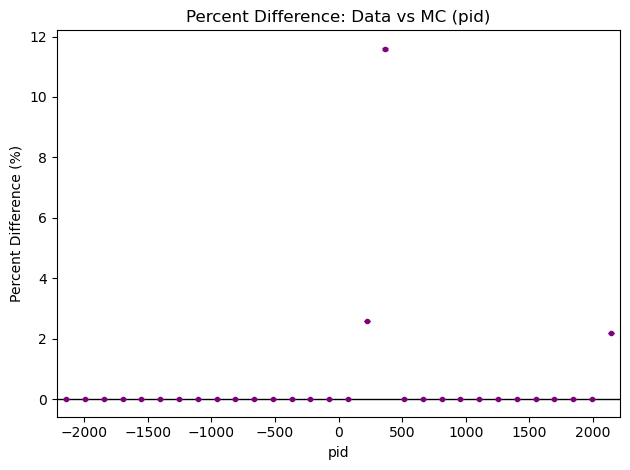

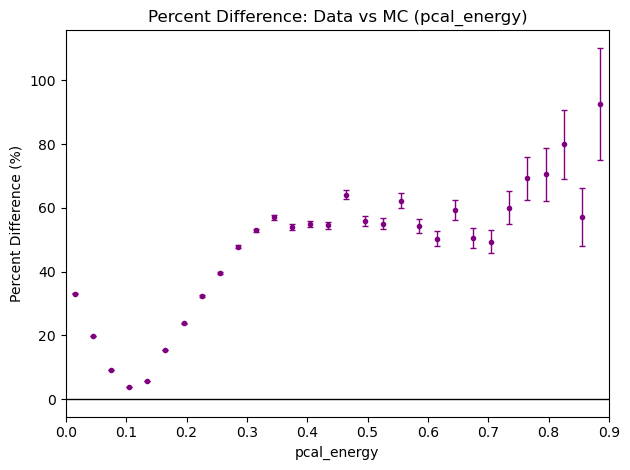

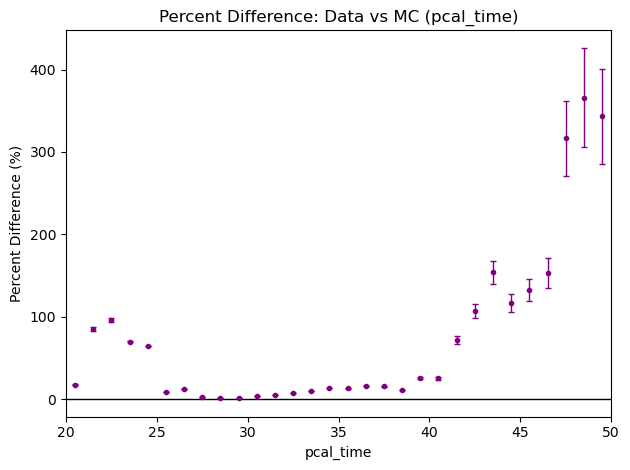

/scratch/slurm/5054438/.cache/tmp/ipykernel_2794473/881264317.py:48: RuntimeWarning: invalid value encountered in divide
  (mc_err[mask] / mc_norm[mask])**2


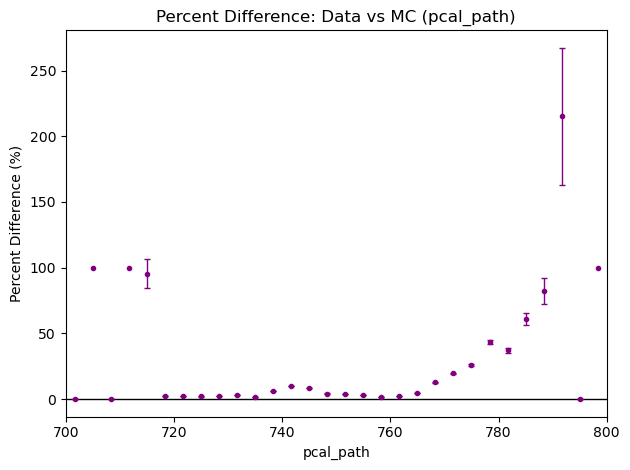

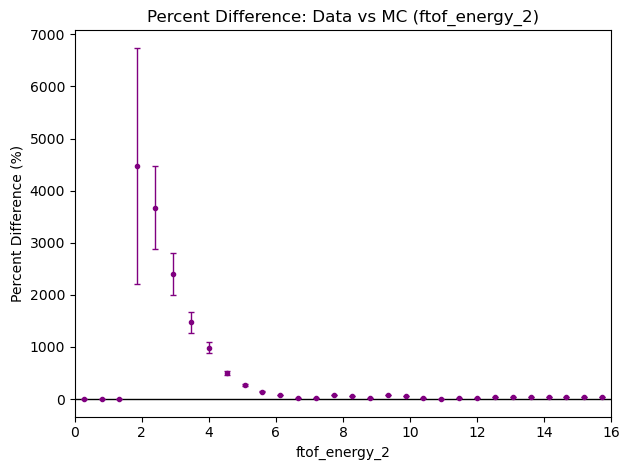

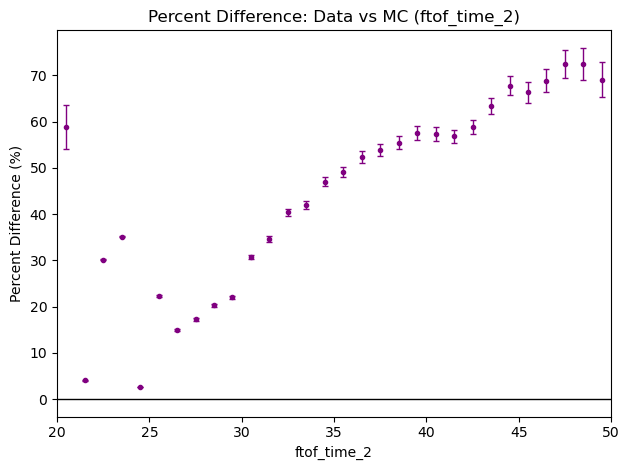

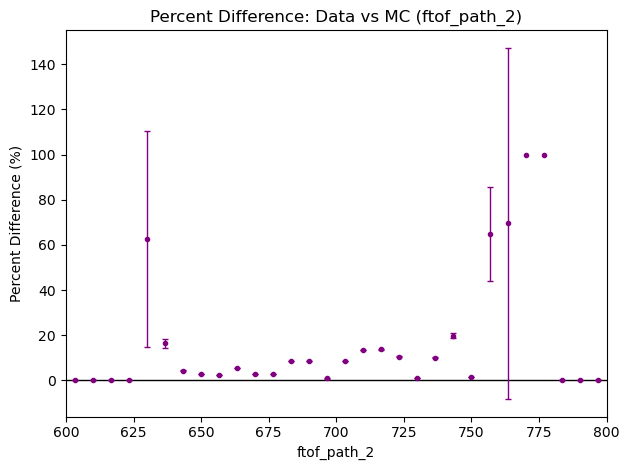

In [9]:
cnt = 0

for varbs in cols:

    real_data = real[real[varbs] != -9999]
    mc_data = df[df[varbs] != -9999]

    rng = (ranges[cnt][0], ranges[cnt][1])
    bins = 30

    # --- raw histograms ---
    real_counts, edges = np.histogram(
        real_data[varbs],
        bins=bins,
        range=rng
    )

    mc_counts, _ = np.histogram(
        mc_data[varbs],
        bins=bins,
        range=rng
    )

    real_tot = real_counts.sum()
    mc_tot = mc_counts.sum()

    # --- normalized histograms ---
    real_norm = real_counts / real_tot
    mc_norm = mc_counts / mc_tot

    # --- uncertainties AFTER normalization ---
    real_err = np.sqrt(real_counts) / real_tot
    mc_err = np.sqrt(mc_counts) / mc_tot

    # --- percent difference ---
    mask = real_norm != 0
    percent_diff = np.zeros_like(real_norm)

    percent_diff[mask] = (
        abs((real_norm[mask] - mc_norm[mask]) / real_norm[mask]
    ) * 100)

    # --- propagated uncertainty on percent diff ---
    percent_err = np.zeros_like(real_norm)

    percent_err[mask] = np.abs(percent_diff[mask]) * np.sqrt(
        (real_err[mask] / real_norm[mask])**2 +
        (mc_err[mask] / mc_norm[mask])**2
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    # --- plot ---
    fig, ax = plt.subplots()

    ax.axhline(0, color="black", linewidth=1)

    ax.errorbar(
        centers,
        percent_diff,
        yerr=percent_err,
        fmt='o',
        color='purple',
        markersize=3,
        elinewidth=1,
        capsize=2
    )

    ax.set_xlabel(varbs)
    ax.set_ylabel("Percent Difference (%)")
    ax.set_title(f"Percent Difference: Data vs MC ({varbs})")
    ax.set_xlim(rng)

    fig.tight_layout()
    fig.savefig(direct + varbs + "Difference.png", dpi=150)

    plt.show()
    allPlots.append(fig)
    plt.close(fig)

    cnt += 1

In [10]:
with PdfPages("/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/subtract/" + "AllPlotsDifference.pdf") as pdf:
    for plot in allPlots:
        pdf.savefig(plot)